# Feature Extraction Demonstration
This outlines how a audio .wav file is converted into a chromagram, and how the chord can be detected using that chromagram.
This example will be done on a C chord.

In [28]:
# Imports
import librosa
import pandas as pd
import xgboost as xgb
%matplotlib inline

## Loading File and Extracting Features
The *librosa* library is used to preform low-level feature extraction such as chromagrams, Mel spectrogram, MFCC, etc.

The audio file is loaded and decoded as a *time series* `y`, represented as a one-dimensional NumPy floating point array. The variable `sr` contains the sampling rate of `y`, that is, the number of samples per second of audio.
By default, all audio is mixed to mono and resampled to 22050 Hz at load time. 

### Chroma Features
Chroma features capture which pitches are present (great for chord identity). In the example below, a C major chord is loaded and the chroma features ar extracted. 

Each of the 12 values tells you how strongly that pitch is present in the audio, regardless of which octave it's in. The closer the value is to 1, the stronger that pitch is. For this chord, we would expect notes C, E and G to be the highest.

In [29]:
# Load C major chord audio file
y, sr = librosa.load('chords-test/C_acoustic_guitar_fender_fa_series_1.wav')

# Compute chroma features
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)

# Show first 5 time steps
# print(chroma[:, :5])

# Average chroma values across time to get a single vector per chord
chroma_mean = chroma.mean(axis=1)
print(f"Average chroma vector: \n{chroma_mean}")  # show average chroma vector

Average chroma vector: 
[0.9801353  0.17391993 0.19715185 0.10917716 0.36052847 0.09246563
 0.0876564  0.38373512 0.13390033 0.16097637 0.15296954 0.21582028]


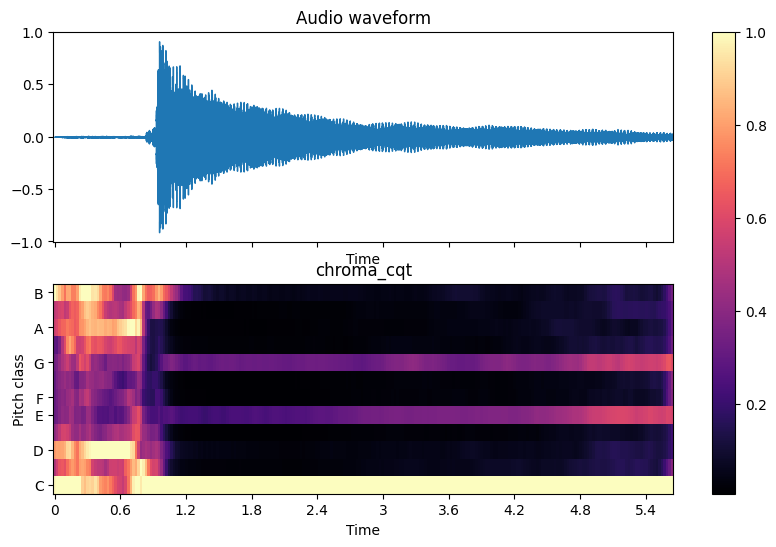

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(10, 6))
img = librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set(title='Audio waveform')
img = librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(title='chroma_cqt')
fig.colorbar(img, ax=ax)

# Training XGBoost on Chroma Features
The training and test dataset is processed into a feature matrix where each chord has 24 features: The mean value and standard deviation for each of the 12 pitch classes.

After loading the training and testing data, it needs to be converted to the expected *DMatrix format*, , which is a optimized data structure for training and prediction.

In [31]:
# Load processed data
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

chroma_cols = [col for col in train_df.columns if col.startswith("feature_")]
X_train = train_df[chroma_cols].values
X_test = test_df[chroma_cols].values

# Encode string labels to integer class ids
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()
y_train = label_enc.fit_transform(train_df["label"])
y_test = label_enc.transform(test_df["label"])

# Helpers to map between ids and chord names
label_mapping = dict(zip(label_enc.classes_, range(len(label_enc.classes_))))
def decode_labels(class_ids):
    return label_enc.inverse_transform(class_ids)

# XGBoost requires the data to be in DMatrix format
train = xgb.DMatrix(X_train, label=y_train)
test = xgb.DMatrix(X_test, label=y_test)

## Hyperparameter Tuning with Bayesian Optimisation
The best parameters can be determined through *Bayesian Optimisation*, a technique that uses *Hyperopt* to tune the model hyperparameters.The optimization process consists of 4 parts which are as follows:
- **1. Initialize domain space**
The domain space is the input values over which we want to search.

- **2. Define objective function**
The objective function can be any function which returns a real value that we want to minimize. 

- **3. Optimization algorithm**
It is the method used to construct the surrogate objective function and choose the next values to evaluate.

- **4. Results**
Results are score or value pairs that the algorithm uses to build the model.

In [32]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
    }

    model = xgb.XGBClassifier(**params, eval_metric='mlogloss', random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return score  # Optuna maximizes by default

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-06-02 16:20:43,271] A new study created in memory with name: no-name-8b7dc747-714d-4e6d-baca-6567369f322b


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-02 16:20:53,230] Trial 0 finished with value: 0.8238095238095238 and parameters: {'max_depth': 5, 'learning_rate': 0.011947050606146509, 'n_estimators': 264, 'subsample': 0.6451059216513783, 'colsample_bytree': 0.749347651042165, 'min_child_weight': 1, 'reg_alpha': 8.295402650278761e-05, 'reg_lambda': 0.0005685302741584264}. Best is trial 0 with value: 0.8238095238095238.
[I 2026-06-02 16:20:57,262] Trial 1 finished with value: 0.8269841269841269 and parameters: {'max_depth': 3, 'learning_rate': 0.1874913284109265, 'n_estimators': 345, 'subsample': 0.6797584467619323, 'colsample_bytree': 0.8353343723409228, 'min_child_weight': 6, 'reg_alpha': 0.00881753605673331, 'reg_lambda': 0.00020982944998468572}. Best is trial 1 with value: 0.8269841269841269.
[I 2026-06-02 16:21:14,207] Trial 2 finished with value: 0.8301587301587302 and parameters: {'max_depth': 8, 'learning_rate': 0.016931265032145048, 'n_estimators': 757, 'subsample': 0.6749977849336997, 'colsample_bytree': 0.941076

In [ ]:
# Start with the best hyperparameters found by Optuna 
best_params = study.best_params
epochs = 10

# Train final model with best hyperparameters
xgb_model = xgb.XGBClassifier(**best_params, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# Evaluate on test set
y_pred = xgb_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))

Best hyperparameters: {'max_depth': 6, 'learning_rate': 0.020555492756414183, 'n_estimators': 676, 'subsample': 0.6360414840161831, 'colsample_bytree': 0.7121268271246294, 'min_child_weight': 2, 'reg_alpha': 0.026465793387956203, 'reg_lambda': 0.0056789469456680055}
[0]	validation_0-mlogloss:3.12618
[1]	validation_0-mlogloss:3.06145
[1]	validation_0-mlogloss:3.06145
[2]	validation_0-mlogloss:3.00542
[3]	validation_0-mlogloss:2.95504
[4]	validation_0-mlogloss:2.90032
[5]	validation_0-mlogloss:2.85405
[6]	validation_0-mlogloss:2.81299
[7]	validation_0-mlogloss:2.77135
[8]	validation_0-mlogloss:2.73278
[9]	validation_0-mlogloss:2.69145
[10]	validation_0-mlogloss:2.65600
[11]	validation_0-mlogloss:2.61920
[12]	validation_0-mlogloss:2.58827
[13]	validation_0-mlogloss:2.55262
[14]	validation_0-mlogloss:2.51818
[15]	validation_0-mlogloss:2.48846
[16]	validation_0-mlogloss:2.45568
[17]	validation_0-mlogloss:2.42330
[18]	validation_0-mlogloss:2.39683
[19]	validation_0-mlogloss:2.37173
[20]	vali

In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=label_enc.classes_,
    columns=label_enc.classes_
)

cm_df

,A,A#,A#m,Am,B,Bm,C,C#,C#m,Cm,...,E,Em,F,F#,F#m,Fm,G,G#,G#m,Gm
A,0,0,0,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A#,0,5,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A#m,0,0,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Am,1,0,0,5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B,0,0,0,0,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bm,0,0,0,0,0,6,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,0,5,0,0,0,...,0,1,0,0,0,0,0,0,0,0
C#,0,0,0,0,0,0,0,6,0,0,...,0,0,0,0,0,0,0,0,0,0
C#m,0,0,0,0,0,0,0,0,4,0,...,1,0,0,1,0,0,0,0,0,0
Cm,0,0,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,0,1
